<a href="https://colab.research.google.com/github/Larenp/image-segmentation-masking/blob/main/REBASE_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Step 1: GPU Setup**
This step checks whether an NVIDIA GPU is available in Google Colab. The GPU will be used to efficiently run the pretrained DINOv2 and SAM models.


In [ ]:
!nvidia-smi

Wed Jul 22 10:58:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             34W /   70W |    9319MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)
print("GPU:", torch.cuda.get_device_name(0))


PyTorch version: 2.11.0+cu128
CUDA available: True
Using device: cuda
GPU: Tesla T4


Step 3: Load **DINOv2** **bold text**
This step loads the pretrained DINOv2 ViT-L/14 model. DINOv2 is used as a frozen feature extractor, meaning its weights are not trained or modified during the REBASE pipeline.**bold text**

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained DINOv2 ViT-L/14
dinov2 = torch.hub.load(
    "facebookresearch/dinov2",
    "dinov2_vitl14"
)

# Move model to GPU
dinov2 = dinov2.to(device)

# Evaluation mode — we are NOT training DINOv2
dinov2.eval()

print("DINOv2 ViT-L/14 loaded successfully")
print("Device:", device)

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


DINOv2 ViT-L/14 loaded successfully
Device: cuda


**Step 4: Load Reference Image**
This step loads the reference image containing the target object or region. Later, a reference mask will specify which part of this image should be identified in the query image.

Original image size: (1085, 720)
Display image size: (800, 531)


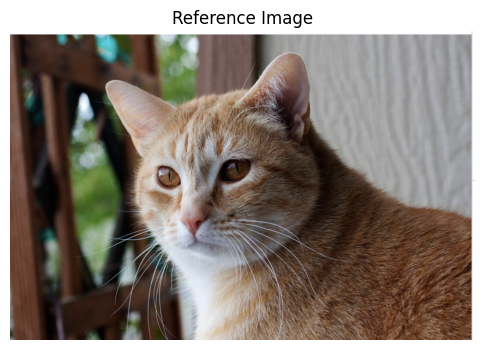

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = "/content/reference.jpg"

image = Image.open(image_path).convert("RGB")

print("Original image size:", image.size)

# Create a smaller copy only for displaying
display_image = image.copy()
display_image.thumbnail((800, 800))

print("Display image size:", display_image.size)

plt.figure(figsize=(6, 6))
plt.imshow(display_image)
plt.axis("off")
plt.title("Reference Image")
plt.show()

**Step 5: Display Reference Image**
The reference image is resized to 518 × 518 pixels, converted into a PyTorch tensor, and normalized. The resulting tensor is moved to the GPU and prepared as input for DINOv2.

In [ ]:
from torchvision import transforms

# DINOv2 preprocessing
transform = transforms.Compose([
    # Resize image to the size used in the REBASE pipeline
    transforms.Resize((518, 518)),

    # Convert PIL image to PyTorch tensor
    transforms.ToTensor(),

    # ImageNet normalization
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# PIL Image -> Tensor
image_tensor = transform(image)

# [3, 518, 518] -> [1, 3, 518, 518]
# The extra dimension represents batch size
image_tensor = image_tensor.unsqueeze(0)

# Move image to the same GPU as DINOv2
image_tensor = image_tensor.to(device)

print("Image tensor shape:", image_tensor.shape)
print("Image tensor device:", image_tensor.device)

Image tensor shape: torch.Size([1, 3, 518, 518])
Image tensor device: cuda:0


**Step 6: Image Preprocessing** preprocessed reference image is passed through the frozen DINOv2 model. Since the model is used only for inference, gradient computation is disabled to reduce memory usag

In [ ]:
import torch

with torch.no_grad():
    features = dinov2.forward_features(image_tensor)

print(features.keys())

dict_keys(['x_norm_clstoken', 'x_norm_regtokens', 'x_norm_patchtokens', 'x_prenorm', 'masks'])


**Step 7: DINOv2 Feature Extraction**
 normalized patch tokens are extracted from DINOv2. With a 518 × 518 input and a patch size of 14 × 14, the image produces a 37 × 37 grid containing 1,369 patch features. Each patch is represented by a 1,024-dimensional feature vector.

In [ ]:
patch_features = features["x_norm_patchtokens"]

print("Patch features shape:", patch_features.shape)

Patch features shape: torch.Size([1, 1369, 1024])


**Step 8: Patch Feature Extraction** 1,369 patch features are reshaped into a 37 × 37 spatial feature grid. This preserves the spatial location of each feature and will later allow the reference mask to distinguish foreground features from background features.

In [ ]:
patch_features_grid = patch_features.reshape(1, 37, 37, 1024)

print("Feature grid shape:", patch_features_grid.shape)

Feature grid shape: torch.Size([1, 37, 37, 1024])


**Step 9: Create Spatial Feature Grid** reference binary mask identifies the target object in the reference image. The white region represents the foreground (target object), while the black region represents the background. REBASE uses this mask to distinguish foreground and background DINOv2 features. The background features will later be used to estimate and eliminate the dominant background feature subspace.

Mask size: (1537, 1023)


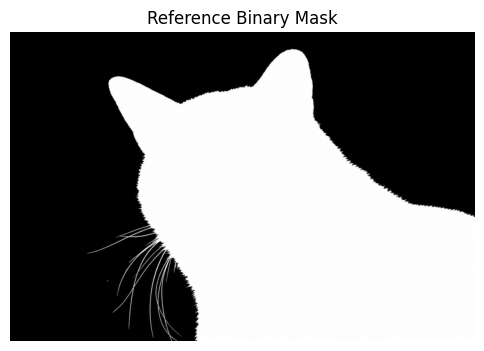

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

# Load reference mask
mask_path = "/content/reference_mask.png"

reference_mask = Image.open(mask_path).convert("L")

print("Mask size:", reference_mask.size)

# Create smaller copy for visualization
display_mask = reference_mask.copy()
display_mask.thumbnail((800, 800))

plt.figure(figsize=(6, 6))
plt.imshow(display_mask, cmap="gray")
plt.axis("off")
plt.title("Reference Binary Mask")
plt.show()

**Step 11: Align Reference Mask with DINOv2 Features**
The reference mask exists at image resolution, while DINOv2 represents the reference image as a 37 × 37 grid of patch features. In this step, the binary mask is resized to the same 37 × 37 spatial resolution. This allows each DINOv2 patch feature to be associated with either the foreground target or the background. REBASE uses area-based resizing to preserve the foreground coverage of patches near object boundaries.

In [ ]:
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

# Load the binary reference mask
mask_path = "/content/reference_mask.png"
reference_mask = Image.open(mask_path).convert("L")

print("Original mask size:", reference_mask.size)

# Convert mask to tensor
mask_tensor = transforms.ToTensor()(reference_mask)

# Add batch dimension
# [1, H, W] -> [1, 1, H, W]
mask_tensor = mask_tensor.unsqueeze(0)

print("Mask tensor shape:", mask_tensor.shape)

# Resize the mask to match DINOv2's 37 x 37 patch grid.
# Area interpolation preserves the approximate foreground
# coverage within each patch.
mask_grid = F.interpolate(
    mask_tensor,
    size=(37, 37),
    mode="area"
)

print("DINO-aligned mask shape:", mask_grid.shape)
print("Minimum value:", mask_grid.min().item())
print("Maximum value:", mask_grid.max().item())

Original mask size: (1537, 1023)
Mask tensor shape: torch.Size([1, 1, 1023, 1537])
DINO-aligned mask shape: torch.Size([1, 1, 37, 37])
Minimum value: 8.79421568242833e-05
Maximum value: 0.9963517785072327


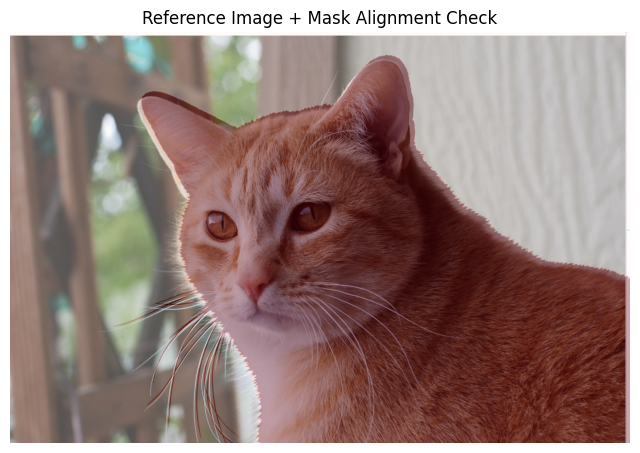

In [ ]:
# Resize mask to reference image size for alignment check
mask_display = reference_mask.resize(image.size)

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.imshow(mask_display, cmap="Reds", alpha=0.35)
plt.title("Reference Image + Mask Alignment Check")
plt.axis("off")
plt.show()

**Separate Foreground and Background Features** DINOv2 feature map contains semantic features for both the target object and the surrounding background. Using the reference mask aligned to the 37 × 37 DINOv2 feature grid, the patch features are separated into foreground and background regions. Foreground features represent the target object, while background features are used by REBASE to estimate the dominant background feature subspace.

In [ ]:
# ============================================================
# STEP 12: SEPARATE FOREGROUND AND BACKGROUND FEATURES
# ============================================================

# Remove batch and channel dimensions from the mask.
# [1, 1, 37, 37] -> [37, 37]
mask_2d = mask_grid[0, 0]

# Remove batch dimension from DINO features.
# [1, 37, 37, 1024] -> [37, 37, 1024]
features_2d = patch_features_grid[0]

print("Mask shape:", mask_2d.shape)
print("Feature grid shape:", features_2d.shape)

Mask shape: torch.Size([37, 37])
Feature grid shape: torch.Size([37, 37, 1024])


In [ ]:
# Threshold used to determine whether a patch is primarily
# foreground or background.

threshold = 0.5

# Patches with more than 50% foreground coverage
foreground_patch_mask = mask_2d >= threshold

# Patches with less than 50% foreground coverage
background_patch_mask = mask_2d < threshold

print(
    "Number of foreground patches:",
    foreground_patch_mask.sum().item()
)

print(
    "Number of background patches:",
    background_patch_mask.sum().item()
)

print(
    "Total patches:",
    foreground_patch_mask.sum().item()
    + background_patch_mask.sum().item()
)

Number of foreground patches: 635
Number of background patches: 734
Total patches: 1369


In [ ]:
# Extract foreground DINOv2 features.
foreground_features = features_2d[
    foreground_patch_mask
]

# Extract background DINOv2 features.
background_features = features_2d[
    background_patch_mask
]

print(
    "Foreground features shape:",
    foreground_features.shape
)

print(
    "Background features shape:",
    background_features.shape
)

Foreground features shape: torch.Size([635, 1024])
Background features shape: torch.Size([734, 1024])


              DINOv2 Feature Grid
                  37 × 37 × 1024
                         │
                         │ Reference Mask
                         ↓
                ┌────────┴────────┐
                ↓                 ↓
          FOREGROUND          BACKGROUND
           FEATURES            FEATURES
                │                 │
                │                 ↓
                │          Background Matrix
                │                X_R
                │                 │
                │                 ↓
                │                SVD
                │                 │
                │                 ↓
                │       Background Subspace B
                │                 │
                └────────┬────────┘
                         ↓
                       REBASE

**Step 13: Background Subspace Estimation using SVD.**
REBASE estimates the dominant semantic directions of the reference background using Singular Value Decomposition (SVD). The background DINOv2 features are decomposed into principal directions, and the most dominant directions are selected to construct a background subspace. This subspace represents common background information that may cause false similarities between the reference and query images. In the next stage, these background directions will be removed from both reference and query features.

In [ ]:
# ============================================================
# STEP 13: ESTIMATE BACKGROUND SUBSPACE USING SVD
# ============================================================

import torch

# background_features shape:
# [Number of background patches, 1024]
X_R = background_features.float()

print("Background feature matrix shape:", X_R.shape)

# Perform Singular Value Decomposition (SVD)
#
# X_R = U @ diag(S) @ Vh
#
# Vh contains the feature-space directions that describe
# the dominant variations in the reference background.
U, S, Vh = torch.linalg.svd(
    X_R,
    full_matrices=False
)

print("U shape:", U.shape)
print("Singular values shape:", S.shape)
print("Vh shape:", Vh.shape)


Background feature matrix shape: torch.Size([734, 1024])
U shape: torch.Size([734, 734])
Singular values shape: torch.Size([734])
Vh shape: torch.Size([734, 1024])


Background DINO Features
        X_R
         │
         ↓
        SVD
         │
    ┌────┼────┐
    ↓    ↓    ↓
    U    S    Vh
         │     │
         │     └── Feature-space directions
         │
         └── Importance of each direction
         

In [ ]:
print("Top 10 singular values:")

for i in range(min(10, len(S))):
    print(f"{i + 1}: {S[i].item():.4f}")

Top 10 singular values:
1: 632.3868
2: 436.8898
3: 349.6843
4: 283.6734
5: 235.8430
6: 221.6080
7: 207.3227
8: 200.2299
9: 184.9650
10: 168.8058


In [ ]:
# Number of background patches
N_B = X_R.shape[0]

# Adaptive rank ratio
r = 0.005

# Number of dominant background directions to retain
s = max(1, int(r * N_B))

print("Number of background patches:", N_B)
print("Selected background subspace rank:", s)

Number of background patches: 734
Selected background subspace rank: 3


In [ ]:
# Select the first s right-singular vectors.
#
# Vh shape: [rank, 1024]
# Vh[:s] shape: [s, 1024]
#
# Transpose to obtain:
# B shape: [1024, s]

B = Vh[:s].T

print("Background basis B shape:", B.shape)

Background basis B shape: torch.Size([1024, 3])


**Step 13 Continued: Eliminate the Background Subspace**After estimating the background basis B using SVD, REBASE removes the feature components that lie within this dominant background subspace. This suppresses background-related information while preserving feature directions that are more useful for distinguishing the target. The same reference-derived background basis will later be applied to the query image features to keep both feature spaces aligned.

In [ ]:
# ============================================================
# STEP 13 (CONTINUED): BACKGROUND SUBSPACE ELIMINATION
# ============================================================

# Original reference feature grid:
# features_2d shape = [37, 37, 1024]

# Flatten spatial dimensions:
# [37, 37, 1024] -> [1369, 1024]
F_R = features_2d.reshape(-1, 1024).float()

print("Original reference features:", F_R.shape)
print("Background basis B:", B.shape)


# ------------------------------------------------------------
# Remove the background subspace
#
# Formula:
# F_R_clean = F_R - (F_R @ B) @ B.T
#
# F_R @ B:
# Measures how much each feature lies along the dominant
# background directions.
#
# (F_R @ B) @ B.T:
# Reconstructs the background component of each feature.
#
# Subtracting it removes that component.
# ------------------------------------------------------------

F_R_clean = F_R - (F_R @ B) @ B.T

print(
    "REBASE-cleaned reference features:",
    F_R_clean.shape
)

Original reference features: torch.Size([1369, 1024])
Background basis B: torch.Size([1024, 3])
REBASE-cleaned reference features: torch.Size([1369, 1024])


**Step 14: Extract and Clean Query Image Features**The query image is a different image containing the same semantic target defined by the reference image and mask. The query image is processed using the same DINOv2 feature extractor to obtain patch-level features. The background subspace B, estimated exclusively from the reference image, is then removed from the query features. Applying the same projection to both reference and query features keeps them in a shared feature space while suppressing background-related directions before cross-image similarity is calculated.


Original query image size: (1104, 723)


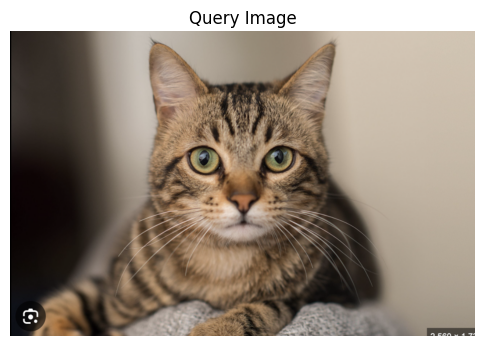

In [ ]:
# ============================================================
# STEP 14: LOAD AND PREPROCESS THE QUERY IMAGE
# ============================================================

from PIL import Image
import matplotlib.pyplot as plt

query_path = "/content/query2.png"

# Load query image
query_image = Image.open(query_path).convert("RGB")

print("Original query image size:", query_image.size)

# Create a smaller copy for visualization
query_display = query_image.copy()
query_display.thumbnail((800, 800))

plt.figure(figsize=(6, 6))
plt.imshow(query_display)
plt.axis("off")
plt.title("Query Image")
plt.show()

In [ ]:
# ============================================================
# PREPROCESS QUERY IMAGE
# ============================================================

# Apply the same DINOv2 preprocessing used for reference image
query_tensor = transform(query_image)

# Add batch dimension
# [3, 518, 518] -> [1, 3, 518, 518]
query_tensor = query_tensor.unsqueeze(0)

# Move to GPU
query_tensor = query_tensor.to(device)

print("Query tensor shape:", query_tensor.shape)
print("Query tensor device:", query_tensor.device)

Query tensor shape: torch.Size([1, 3, 518, 518])
Query tensor device: cuda:0


In [ ]:
# ============================================================
# EXTRACT QUERY DINOV2 PATCH FEATURES
# ============================================================

with torch.no_grad():
    query_outputs = dinov2.forward_features(query_tensor)

# Extract normalized patch tokens
query_patch_features = query_outputs["x_norm_patchtokens"]

print(
    "Query patch features:",
    query_patch_features.shape
)

Query patch features: torch.Size([1, 1369, 1024])


In [ ]:
# Remove batch dimension
# [1, 1369, 1024] -> [1369, 1024]

F_Q = query_patch_features[0].float()

print(
    "Original query features:",
    F_Q.shape
)

Original query features: torch.Size([1369, 1024])


In [ ]:
# ============================================================
# APPLY REBASE BACKGROUND ELIMINATION TO QUERY FEATURES
# ============================================================

# IMPORTANT:
# B was learned from the REFERENCE background.
# We do NOT calculate a new B from the query image.
#
# Formula:
# F_Q_clean = F_Q - (F_Q @ B) @ B.T

F_Q_clean = F_Q - (F_Q @ B) @ B.T

print(
    "REBASE-cleaned query features:",
    F_Q_clean.shape
)

REBASE-cleaned query features: torch.Size([1369, 1024])


In [ ]:
query_difference = torch.norm(
    F_Q - F_Q_clean
).item()

print(
    "Difference after query background elimination:",
    query_difference
)

Difference after query background elimination: 669.5576782226562


In [ ]:
# [1369, 1024] -> [37, 37, 1024]

F_Q_clean_grid = F_Q_clean.reshape(
    37,
    37,
    1024
)

print(
    "Cleaned query feature grid:",
    F_Q_clean_grid.shape
)

Cleaned query feature grid: torch.Size([37, 37, 1024])


              REFERENCE
                  │
              Reference Mask
                  │
                  ↓
                DINOv2
                  │
                  ↓
                 F_R
                  │
       Background Features
                  │
                  ↓
                 SVD
                  │
                  ↓
         Background Basis B
                  │
          ┌───────┴───────┐
          ↓               ↓
         F_R             F_Q
          │               │
          ↓               ↓
       Remove B         Remove B
          │               │
          ↓               ↓
       F̃_R              F̃_Q
          │               │
          └───────┬───────┘
                  ↓
          Similarity Mapping
               [NEXT]

**Step 15: Generate the Reference-to-Query Similarity Map.**After background-subspace elimination, REBASE computes semantic correspondence between the reference foreground and the query image. The foreground coverage values from the reference mask are used to weight the cleaned reference patch features. Cosine similarity is then calculated between the weighted reference prototypes and every cleaned query patch. The maximum similarity at each query location produces a 37 × 37 similarity map indicating regions that most strongly correspond to the reference target.


In [ ]:
# ============================================================
# STEP 15: PREPARE WEIGHTED REFERENCE FOREGROUND PROTOTYPES
# ============================================================

import torch
import torch.nn.functional as F

# Flatten the soft reference mask:
# [37, 37] -> [1369]
mask_weights = mask_2d.reshape(-1).float().to(F_R_clean.device)

# Select patches that contain foreground.
# We keep patches with non-zero foreground coverage.
foreground_indices = mask_weights > 0

# Select cleaned reference foreground features.
reference_fg_features = F_R_clean[foreground_indices]

# Get corresponding soft foreground weights.
reference_fg_weights = mask_weights[foreground_indices]

# Weight each reference feature by its foreground coverage.
weighted_reference_fg = (
    reference_fg_features *
    reference_fg_weights.unsqueeze(1)
)

print(
    "Reference foreground prototypes:",
    weighted_reference_fg.shape
)

Reference foreground prototypes: torch.Size([1369, 1024])


In [ ]:
# ============================================================
# NORMALIZE FEATURES FOR COSINE SIMILARITY
# ============================================================

# Normalize reference foreground prototypes.
reference_fg_normalized = F.normalize(
    weighted_reference_fg,
    p=2,
    dim=1
)

# Normalize cleaned query features.
query_normalized = F.normalize(
    F_Q_clean,
    p=2,
    dim=1
)

print(
    "Normalized reference features:",
    reference_fg_normalized.shape
)

print(
    "Normalized query features:",
    query_normalized.shape
)

Normalized reference features: torch.Size([1369, 1024])
Normalized query features: torch.Size([1369, 1024])


In [ ]:
# ============================================================
# COMPUTE CROSS-IMAGE COSINE SIMILARITY
# ============================================================

# Each reference foreground prototype is compared with
# every query patch.
#
# Output shape:
# [Number of reference foreground patches, 1369]

similarity_matrix = (
    reference_fg_normalized @ query_normalized.T
)

print(
    "Similarity matrix shape:",
    similarity_matrix.shape
)

Similarity matrix shape: torch.Size([1369, 1369])


In [ ]:
# ============================================================
# CREATE QUERY SIMILARITY MAP
# ============================================================

# For every query patch, take its strongest correspondence
# with any reference foreground prototype.

similarity_scores, _ = similarity_matrix.max(dim=0)

print(
    "Similarity scores shape:",
    similarity_scores.shape
)

# [1369] -> [37, 37]
similarity_map = similarity_scores.reshape(37, 37)

print(
    "Similarity map shape:",
    similarity_map.shape
)

Similarity scores shape: torch.Size([1369])
Similarity map shape: torch.Size([37, 37])


In [ ]:
# ============================================================
# CREATE QUERY SIMILARITY MAP
# ============================================================

# For every query patch, take its strongest correspondence
# with any reference foreground prototype.

similarity_scores, _ = similarity_matrix.max(dim=0)

print(
    "Similarity scores shape:",
    similarity_scores.shape
)

# [1369] -> [37, 37]
similarity_map = similarity_scores.reshape(37, 37)

print(
    "Similarity map shape:",
    similarity_map.shape
)

Similarity scores shape: torch.Size([1369])
Similarity map shape: torch.Size([37, 37])


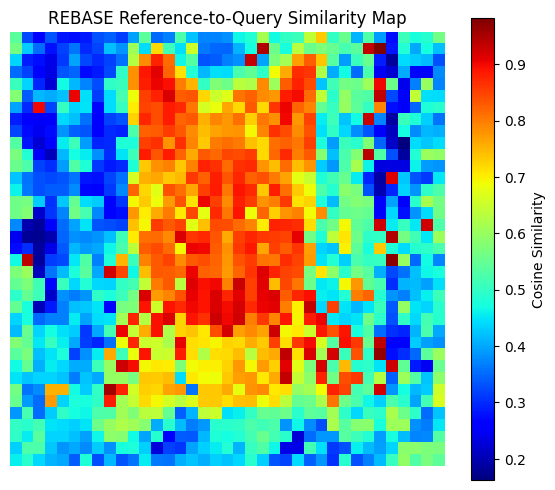

In [ ]:
# ============================================================
# VISUALIZE REBASE SIMILARITY MAP
# ============================================================

similarity_map_cpu = (
    similarity_map
    .detach()
    .cpu()
    .numpy()
)

plt.figure(figsize=(7, 6))

plt.imshow(
    similarity_map_cpu,
    cmap="jet"
)

plt.colorbar(
    label="Cosine Similarity"
)

plt.title(
    "REBASE Reference-to-Query Similarity Map"
)

plt.axis("off")

plt.show()

```text
Reference Cat + Mask
        │
        ↓
      DINOv2
        │
        ↓
Background Subspace B
        │
        ├──────────────────┐
        ↓                  ↓
Clean Reference       Clean Query
Features              Features
        │                  │
        ↓                  │
Reference Foreground       │
Prototypes                 │
        │                  │
        └────────┬─────────┘
                 ↓
          Cosine Similarity
                 ↓
            37 × 37 Map
                 ↓
          High Similarity
                 ↓
         Probable Target
```

**Step 16: Similarity-Weighted Farthest-Point Sampling (SW-FPS)**The similarity map identifies query regions that are semantically related to the reference target. Simply selecting the highest-scoring points may cause all prompts to cluster in a small region. SW-FPS balances semantic similarity with spatial diversity. The first point is selected from the location with the highest similarity, while subsequent points are chosen based on both their similarity score and their distance from previously selected points. The selected points will later be used as positive point prompts for SAM.

In [ ]:
import torch

def sw_fps_fixed(
    similarity_map,
    K=8,
    alpha=0.5,
    similarity_percentile=70
):
    """
    Similarity-Weighted Farthest Point Sampling
    restricted to high-similarity candidate regions.
    """

    H, W = similarity_map.shape

    # Flatten similarity map
    similarity_flat = similarity_map.flatten()

    # Normalize similarity to [0, 1]
    sim_min = similarity_flat.min()
    sim_max = similarity_flat.max()

    normalized_similarity = (
        similarity_flat - sim_min
    ) / (sim_max - sim_min + 1e-8)

    # ---------------------------------------------------------
    # FIX:
    # Only allow high-similarity locations to become candidates
    # ---------------------------------------------------------

    threshold = torch.quantile(
        normalized_similarity,
        similarity_percentile / 100.0
    )

    candidate_mask = (
        normalized_similarity >= threshold
    )

    candidate_indices = torch.where(
        candidate_mask
    )[0]

    print(
        "Number of candidate patches:",
        len(candidate_indices)
    )

    # Create coordinates for entire 37x37 grid
    y_coords, x_coords = torch.meshgrid(
        torch.arange(
            H,
            device=similarity_map.device
        ),
        torch.arange(
            W,
            device=similarity_map.device
        ),
        indexing="ij"
    )

    all_coordinates = torch.stack(
        [
            y_coords.flatten(),
            x_coords.flatten()
        ],
        dim=1
    ).float()

    # Keep only high-similarity candidates
    candidate_coordinates = (
        all_coordinates[candidate_indices]
    )

    candidate_similarity = (
        normalized_similarity[candidate_indices]
    )

    # First point = highest similarity
    first_local_index = torch.argmax(
        candidate_similarity
    )

    selected_local_indices = [
        first_local_index.item()
    ]

    # Select remaining points
    for _ in range(1, K):

        selected_coordinates = (
            candidate_coordinates[
                selected_local_indices
            ]
        )

        # Distance from candidates to selected points
        distances = torch.cdist(
            candidate_coordinates,
            selected_coordinates
        )

        # Distance to nearest selected point
        min_distances = distances.min(
            dim=1
        ).values

        # Normalize distance
        normalized_distances = (
            min_distances /
            (min_distances.max() + 1e-8)
        )

        # Combine similarity + spatial diversity
        score = (
            alpha * normalized_distances
            +
            (1 - alpha) * candidate_similarity
        )

        # Prevent duplicate selection
        score[selected_local_indices] = -float("inf")

        next_local_index = torch.argmax(score)

        selected_local_indices.append(
            next_local_index.item()
        )

    # Convert selected candidates to grid coordinates
    selected_points = []

    for local_index in selected_local_indices:

        global_index = candidate_indices[
            local_index
        ].item()

        y = global_index // W
        x = global_index % W

        selected_points.append(
            (y, x)
        )

    return selected_points

In [ ]:
# Select 8 spatially distributed positive points

K = 8
alpha = 0.5

selected_points = sw_fps(
    similarity_map,
    K=K,
    alpha=alpha
)

print("Selected SW-FPS points:")

for i, point in enumerate(selected_points):
    print(
        f"Point {i + 1}: {point}"
    )

Selected SW-FPS points:
Point 1: (1, 31)
Point 2: (30, 8)
Point 3: (27, 31)
Point 4: (5, 5)
Point 5: (15, 19)
Point 6: (19, 1)
Point 7: (16, 35)
Point 8: (2, 20)


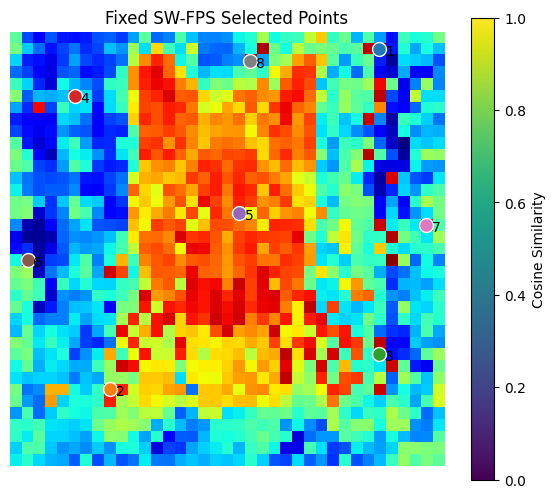

In [ ]:
# ============================================================
# VISUALIZE SW-FPS POINTS ON SIMILARITY MAP
# ============================================================

plt.figure(figsize=(7, 6))

plt.imshow(
    similarity_map.detach().cpu().numpy(),
    cmap="jet"
)

for i, (y, x) in enumerate(selected_points):

    plt.scatter(
        x,
        y,
        s=100,
        edgecolors="white"
    )

    plt.text(
        x + 0.5,
        y + 0.5,
        str(i + 1),
        fontsize=10
    )

plt.colorbar(
    label="Cosine Similarity"
)

plt.title(
    "Fixed SW-FPS Selected Points"
)

plt.axis("off")

plt.show()

```text
Similarity Map
      │
      ↓
    SW-FPS
      │
      ↓
8 High-Similarity
Spatially Distributed
Points
      │
      ↓
Positive Point Prompts
for SAM

**Step 17: Create the Dense Similarity Prior.**The REBASE similarity map provides dense information about where the reference target is likely to appear in the query image. In addition to the sparse SW-FPS point prompts, this similarity map is processed into a dense prior for SAM. The similarity values are standardized, probable foreground regions are identified, and morphological erosion is applied to obtain more reliable background regions. The resulting map will later be resized and passed through SAM's dense mask-input pathway

In [ ]:
# ============================================================
# STEP 17: GENERATE DENSE SIMILARITY PRIOR
# ============================================================

import torch
import torch.nn.functional as F

# Start from the REBASE similarity map
# Shape: [37, 37]

sim_map = similarity_map.float()

# Calculate mean and standard deviation
sim_mean = sim_map.mean()
sim_std = sim_map.std()

# Z-score normalization
z_map = (
    sim_map - sim_mean
) / (
    sim_std + 1e-8
)

print("Z-map shape:", z_map.shape)
print("Z-map mean:", z_map.mean().item())
print("Z-map std:", z_map.std().item())

Z-map shape: torch.Size([37, 37])
Z-map mean: 1.497735446776005e-08
Z-map std: 0.9999998807907104


In [ ]:
# Locations with above-average similarity
# are considered probable foreground regions.

foreground_estimate = (z_map > 0).float()

print(
    "Foreground estimate shape:",
    foreground_estimate.shape
)

print(
    "Number of probable foreground patches:",
    foreground_estimate.sum().item()
)

Foreground estimate shape: torch.Size([37, 37])
Number of probable foreground patches: 584.0


In [ ]:
# Add batch and channel dimensions
# [37, 37] -> [1, 1, 37, 37]

fg = foreground_estimate.unsqueeze(0).unsqueeze(0)

# Binary erosion
eroded_fg = 1 - F.max_pool2d(
    1 - fg,
    kernel_size=3,
    stride=1,
    padding=1
)

# Return to [37, 37]
eroded_fg = eroded_fg[0, 0]

print("Eroded foreground shape:", eroded_fg.shape)
print("Remaining foreground patches:", eroded_fg.sum().item())

Eroded foreground shape: torch.Size([37, 37])
Remaining foreground patches: 342.0


In [ ]:
# Start with normalized similarity values
dense_prior = z_map.clone()

# Regions outside the eroded foreground
# are treated as confident background
confident_background = (eroded_fg == 0)

# Assign negative logit to background
dense_prior[confident_background] = -2.0

print("Dense prior shape:", dense_prior.shape)
print("Minimum:", dense_prior.min().item())
print("Maximum:", dense_prior.max().item())

Dense prior shape: torch.Size([37, 37])
Minimum: -2.0
Maximum: 1.808842420578003


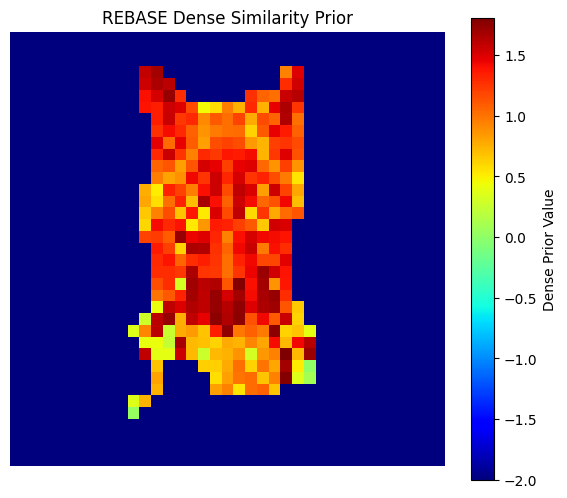

In [ ]:
plt.figure(figsize=(7, 6))

plt.imshow(
    dense_prior.detach().cpu().numpy(),
    cmap="jet"
)

plt.colorbar(label="Dense Prior Value")
plt.title("REBASE Dense Similarity Prior")
plt.axis("off")

plt.show()

In [ ]:
# Add batch and channel dimensions
# [37, 37] -> [1, 1, 37, 37]

dense_prior_input = dense_prior.unsqueeze(0).unsqueeze(0)

# Resize to SAM's low-resolution mask-input size
dense_prior_sam = F.interpolate(
    dense_prior_input,
    size=(256, 256),
    mode="bilinear",
    align_corners=False
)

print("Dense prior for SAM:", dense_prior_sam.shape)

Dense prior for SAM: torch.Size([1, 1, 256, 256])


Step 18: Set Up the Segment Anything Model (SAM)

SAM is used as the final segmentation model in the REBASE pipeline. DINOv2 and REBASE identify where the reference target is likely to appear in the query image, while SW-FPS provides sparse positive point prompts and the dense similarity prior provides additional spatial guidance. These prompts are passed to SAM to generate the final segmentation mask. Like DINOv2, SAM is used as a pretrained frozen model and does not require additional training.

In [ ]:
!pip install -q git+https://github.com/facebookresearch/segment-anything.git


  Preparing metadata (setup.py) ... done


In [ ]:
import torch
from segment_anything import sam_model_registry, SamPredictor

print("SAM package imported successfully.")

SAM package imported successfully.


In [344]:
!wget -q \
https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth \
-O /content/sam_vit_h_4b8939.pth

In [345]:
import os

sam_checkpoint = "/content/sam_vit_h_4b8939.pth"

print("Checkpoint exists:", os.path.exists(sam_checkpoint))

if os.path.exists(sam_checkpoint):
    print(
        "Checkpoint size:",
        round(os.path.getsize(sam_checkpoint) / (1024**3), 2),
        "GB"
    )

Checkpoint exists: True
Checkpoint size: 2.39 GB


In [346]:
# ============================================================
# LOAD PRETRAINED SAM ViT-H
# ============================================================

sam_checkpoint = "/content/sam_vit_h_4b8939.pth"

sam = sam_model_registry["vit_h"](
    checkpoint=sam_checkpoint
)

# Move SAM to GPU
sam = sam.to(device)

# Evaluation mode
sam.eval()

print("SAM ViT-H loaded successfully.")
print("Device:", device)

SAM ViT-H loaded successfully.
Device: cuda


In [ ]:
dinov2 = dinov2.cpu()

torch.cuda.empty_cache()

print("DINOv2 moved to CPU.")
print("GPU cache cleared.")

In [348]:
# Create SAM predictor interface

predictor = SamPredictor(sam)

print("SAM Predictor created successfully.")

SAM Predictor created successfully.


```
Reference + Mask
       │
       ↓
     DINOv2
       │
       ↓
     REBASE
       │
       ├─────────────── Query + DINOv2
       │
       ↓
Similarity Map
       │
   ┌───┴───┐
   ↓       ↓
SW-FPS   Dense Prior
8 Points   256×256
   │       │
   └───┬───┘
       ↓
   SAM ViT-H     ← WE ARE HERE
       ↓
Predicted Mask

Step 19: Prepare the Query Image and Convert SW-FPS Points

The SW-FPS points are currently represented in the 37 × 37 DINOv2 feature grid. SAM, however, expects point prompts in the coordinate system of the original query image. Therefore, the selected points are mapped from DINOv2 patch-grid coordinates to their corresponding locations in the original query image. The query image is then provided to SAM so that its image encoder can generate the image embedding required for final segmentation.


In [349]:
# ============================================================
# STEP 19: PREPARE QUERY IMAGE FOR SAM
# ============================================================

import numpy as np

# Convert PIL query image to NumPy RGB array
query_np = np.array(query_image)

print("Query image shape:", query_np.shape)

Query image shape: (723, 1104, 3)


In [350]:
query_height, query_width = query_np.shape[:2]

print("Query width:", query_width)
print("Query height:", query_height)

Query width: 1104
Query height: 723


In [351]:
# ============================================================
# CONVERT 37x37 DINO GRID POINTS TO ORIGINAL IMAGE COORDINATES
# ============================================================

sam_points = []

for y, x in selected_points:

    # Convert patch center to normalized position.
    # +0.5 places the point approximately at the center
    # of the selected DINO patch.

    x_original = (
        (x + 0.5) / 37
    ) * query_width

    y_original = (
        (y + 0.5) / 37
    ) * query_height

    sam_points.append([
        x_original,
        y_original
    ])

sam_points = np.array(
    sam_points,
    dtype=np.float32
)

print("SAM point coordinates:")
print(sam_points)

print(
    "SAM points shape:",
    sam_points.shape
)

SAM point coordinates:
[[ 939.8919     29.31081 ]
 [ 253.62163   595.9865  ]
 [ 939.8919    537.36487 ]
 [ 164.10811   107.47298 ]
 [ 581.8378    302.8784  ]
 [  44.756756  381.04053 ]
 [1059.2433    322.4189  ]
 [ 611.67566    48.851353]]
SAM points shape: (8, 2)


In [352]:
# All SW-FPS points are positive foreground prompts

sam_point_labels = np.ones(
    len(sam_points),
    dtype=np.int32
)

print("Point labels:", sam_point_labels)
print("Labels shape:", sam_point_labels.shape)

Point labels: [1 1 1 1 1 1 1 1]
Labels shape: (8,)


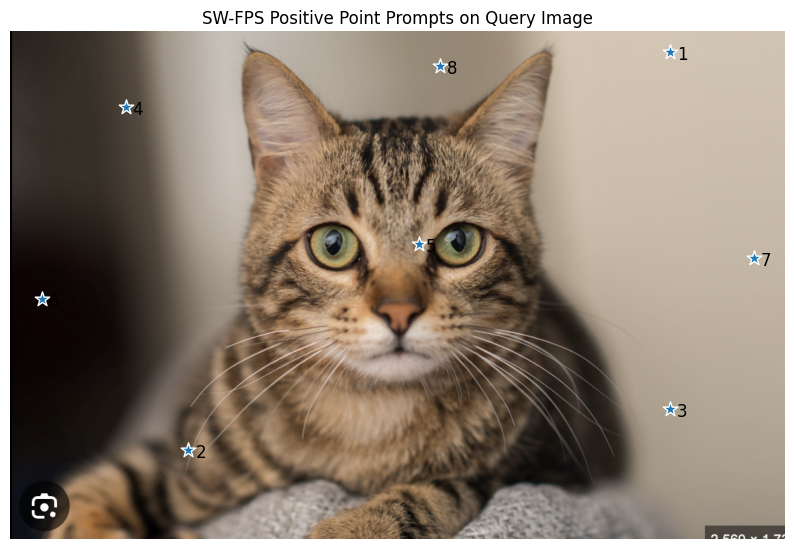

In [353]:
# ============================================================
# VISUALIZE SW-FPS POINTS ON QUERY IMAGE
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.imshow(query_np)

plt.scatter(
    sam_points[:, 0],
    sam_points[:, 1],
    s=120,
    marker="*",
    edgecolors="white"
)

for i, (x, y) in enumerate(sam_points):

    plt.text(
        x + 10,
        y + 10,
        str(i + 1),
        fontsize=12
    )

plt.title(
    "SW-FPS Positive Point Prompts on Query Image"
)

plt.axis("off")

plt.show()

In [354]:
# ============================================================
# COMPUTE SAM IMAGE EMBEDDING
# ============================================================

predictor.set_image(query_np)

print(
    "Query image successfully encoded by SAM."
)

Query image successfully encoded by SAM.


```
               QUERY IMAGE
                    │
           ┌────────┴────────┐
           ↓                 ↓
        DINOv2              SAM
           │                 │
           ↓                 ↓
       REBASE           Image Embedding
           │                 │
           ↓                 │
     Similarity Map          │
           │                 │
      ┌────┴────┐            │
      ↓         ↓            │
    SW-FPS   Dense Prior     │
      ↓         ↓            │
   8 Points    256×256       │
      │         │            │
      └────┬────┴────────────┘
           ↓
     SAM Mask Decoder
           ↓
   FINAL QUERY MASK
          [NEXT]

Step 20: Generate the Final Segmentation Mask with SAM

In this step, the sparse SW-FPS point prompts and the dense REBASE similarity prior are provided to SAM. The SW-FPS points indicate high-confidence target locations, while the dense prior provides broader spatial information about probable foreground and background regions. SAM combines these prompts with the query image embedding to generate the final segmentation mask.

In [ ]:
predictor.set_image(query_np)

In [356]:
# ============================================================
# PREPARE REBASE DENSE PRIOR FOR SAM
# ============================================================

mask_input = (
    dense_prior_sam
    .squeeze(0)
    .detach()
    .cpu()
    .numpy()
    .astype(np.float32)
)

print("SAM mask input shape:", mask_input.shape)

SAM mask input shape: (1, 256, 256)


In [357]:
# ============================================================
# GENERATE FINAL SEGMENTATION WITH SAM
# ============================================================

masks, scores, logits = predictor.predict(
    point_coords=sam_points,
    point_labels=sam_point_labels,
    mask_input=mask_input,
    multimask_output=True
)

print("Number of masks:", len(masks))
print("Masks shape:", masks.shape)
print("SAM confidence scores:", scores)

Number of masks: 3
Masks shape: (3, 723, 1104)
SAM confidence scores: [0.74971485 0.9855969  0.9704536 ]


In [358]:
# Select SAM's highest-confidence prediction

best_mask_index = np.argmax(scores)

final_mask = masks[best_mask_index]

final_score = scores[best_mask_index]

print("Selected mask:", best_mask_index)
print("SAM confidence score:", final_score)
print("Final mask shape:", final_mask.shape)

Selected mask: 1
SAM confidence score: 0.9855969
Final mask shape: (723, 1104)


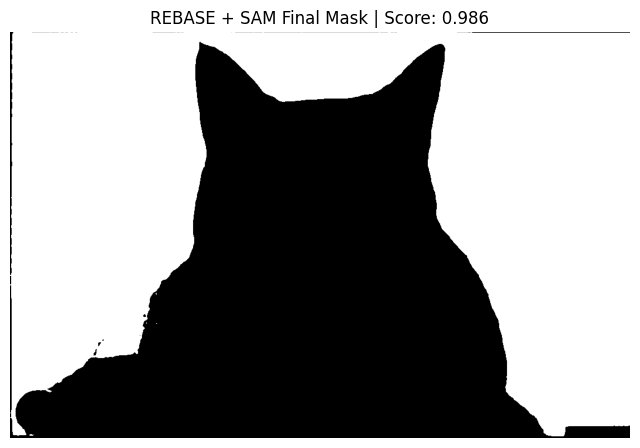

In [359]:
# ============================================================
# VISUALIZE FINAL SEGMENTATION MASK
# ============================================================

plt.figure(figsize=(8, 8))

plt.imshow(
    final_mask,
    cmap="gray"
)

plt.title(
    f"REBASE + SAM Final Mask | Score: {final_score:.3f}"
)

plt.axis("off")

plt.show()

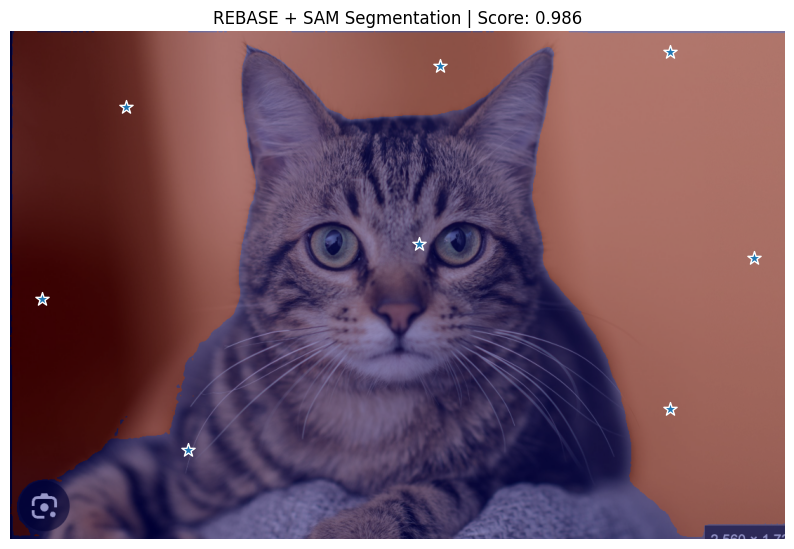

In [360]:
# ============================================================
# VISUALIZE SEGMENTATION OVERLAY
# ============================================================

plt.figure(figsize=(10, 8))

# Original query image
plt.imshow(query_np)

# Predicted segmentation overlay
plt.imshow(
    final_mask,
    cmap="jet",
    alpha=0.4
)

# Display SW-FPS points
plt.scatter(
    sam_points[:, 0],
    sam_points[:, 1],
    s=100,
    marker="*",
    edgecolors="white"
)

plt.title(
    f"REBASE + SAM Segmentation | Score: {final_score:.3f}"
)

plt.axis("off")

plt.show()

```
Reference Image + Mask           Query Image
         │                           │
         └────────→ DINOv2 ←────────┘
                      │
                      ↓
            Background Subspace
                      │
                      ↓
                    REBASE
                      │
                      ↓
              Similarity Map
                      │
                ┌─────┴─────┐
                ↓           ↓
              SW-FPS    Dense Prior
                │           │
              8 Points    256×256
                │           │
                └─────┬─────┘
                      ↓
                     SAM
                      ↓
             FINAL QUERY MASK

Step 21: Save and Evaluate the Final Segmentation Result

The final binary segmentation mask generated by REBASE and SAM is saved as an image for further analysis. If a ground-truth mask for the query image is available, segmentation performance can also be quantitatively evaluated using metrics such as Intersection over Union (IoU).

In [361]:
from PIL import Image
import numpy as np

# Convert boolean mask to 0-255 image
final_mask_uint8 = (
    final_mask.astype(np.uint8) * 255
)

# Save mask
output_mask = Image.fromarray(final_mask_uint8)

output_path = "/content/rebase_final_mask.png"

output_mask.save(output_path)

print("Final mask saved to:", output_path)

Final mask saved to: /content/rebase_final_mask.png


In [362]:
from google.colab import files

files.download("/content/rebase_final_mask.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

```
CORE REBASE PIPELINE
====================

Reference Image + Mask
        │
        ↓
DINOv2 Features
        │
        ↓
Background Subspace (SVD)
        │
        ↓
Background Elimination
        │
        ├──────── Query Features
        │
        ↓
Cross-Image Similarity
        │
        ↓
Similarity Map
        │
   ┌────┴────┐
   ↓         ↓
 SW-FPS   Dense Prior
   │         │
   └────┬────┘
        ↓
       SAM
        ↓
Predicted Query Mask
        │
        ↓
Save + Evaluate

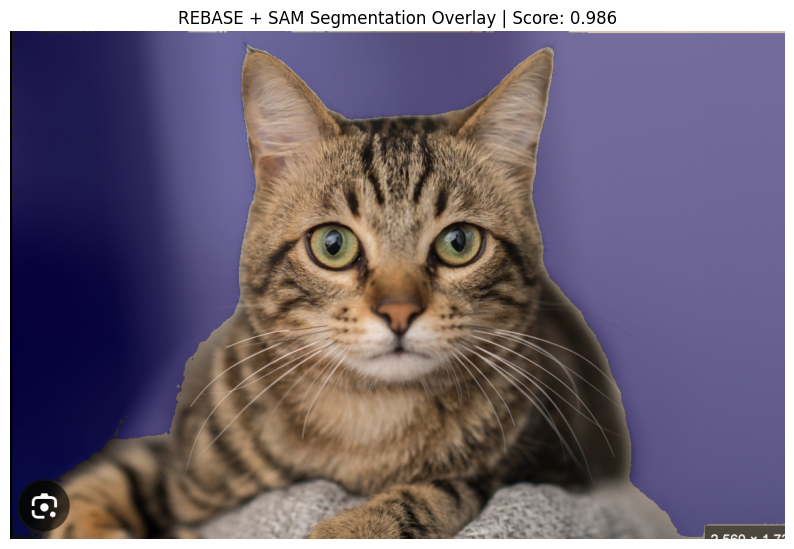

In [363]:
import matplotlib.pyplot as plt
import numpy as np

# Original query image
plt.figure(figsize=(10, 8))
plt.imshow(query_np)

# Overlay only the predicted foreground region
masked_overlay = np.ma.masked_where(
    ~final_mask.astype(bool),
    final_mask
)

plt.imshow(
    masked_overlay,
    cmap="jet",
    alpha=0.45
)

plt.title(
    f"REBASE + SAM Segmentation Overlay | Score: {final_score:.3f}"
)

plt.axis("off")
plt.show()

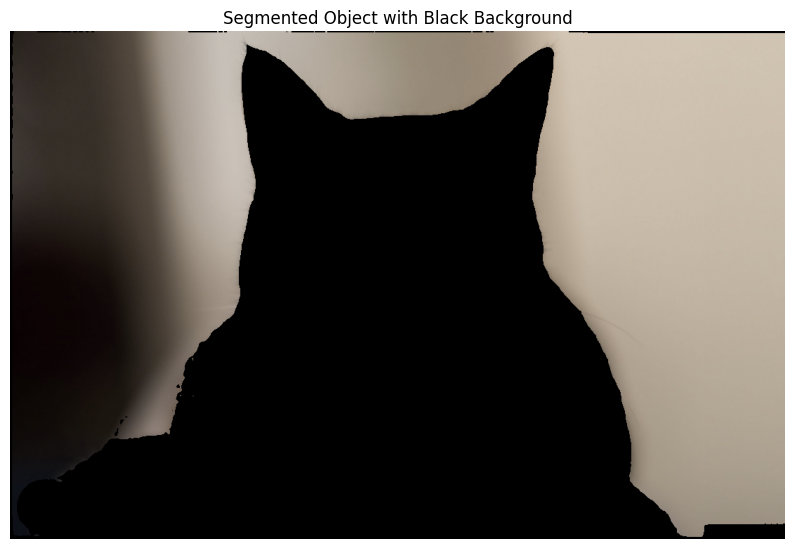

In [364]:
import matplotlib.pyplot as plt
import numpy as np

# Make sure mask is boolean
mask_bool = final_mask.astype(bool)

# Create a completely black image
result = np.zeros_like(query_np)

# Copy original image pixels only where the mask is True
result[mask_bool] = query_np[mask_bool]

# Display result
plt.figure(figsize=(10, 8))
plt.imshow(result)
plt.title("Segmented Object with Black Background")
plt.axis("off")
plt.show()

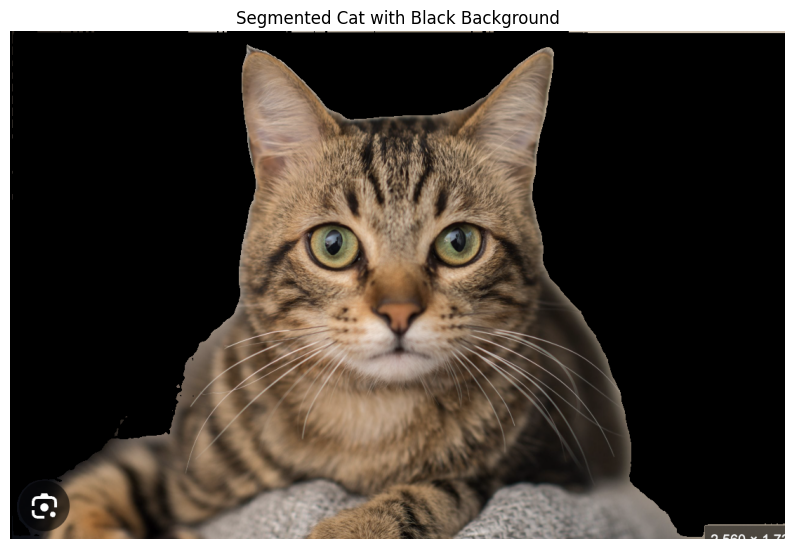

In [365]:
import matplotlib.pyplot as plt
import numpy as np

# Convert mask to boolean and INVERT it
mask_bool = ~final_mask.astype(bool)

# Create black background
result = np.zeros_like(query_np)

# Keep original RGB pixels only for the cat
result[mask_bool] = query_np[mask_bool]

plt.figure(figsize=(10, 8))
plt.imshow(result)
plt.title("Segmented Cat with Black Background")
plt.axis("off")
plt.show()